# Lista 2 — ARMA e Filtro Empírico

**Disciplina:** Econometria das Séries Temporais Aplicada a Macroeconomia e Finanças — 2º semestre de 2026

Este trabalho apresenta a resolução dos três blocos propostos no Exercício 2: (A) modelagem ARMA de uma série artificial gerada com inovações não gaussianas, (B) modelagem ARIMA de uma série macroeconômica real e (C) decomposição da mesma série real em componentes de tendência e ciclo por meio de três filtros distintos.

## Configuração inicial

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.tsa.filters.hp_filter import hpfilter

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.precision", 4)

RNG_SEED = 42

## Bloco A — Modelagem ARMA de série artificial

Foi gerada uma série artificial $y_t$ com $n=50$ observações, seguindo um processo ARMA(2,2) estacionário e inversível:

$$y_t = \phi_1 y_{t-1} + \phi_2 y_{t-2} + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2}$$

com inovações $\epsilon_t \sim t_{(3)}$ (distribuição *t*-Student com 3 graus de liberdade), escolhida por apresentar caudas mais pesadas do que a normal, produzindo choques ocasionalmente extremos. Os coeficientes escolhidos foram $\phi_1 = 0{,}6$, $\phi_2 = -0{,}3$, $\theta_1 = 0{,}5$ e $\theta_2 = 0{,}3$. Antes da simulação, verificou-se que essa combinação satisfaz as condições de estacionariedade (raízes do polinômio autorregressivo fora do círculo unitário) e de inversibilidade (raízes do polinômio de médias móveis fora do círculo unitário).

In [2]:
phi1, phi2 = 0.6, -0.3
theta1, theta2 = 0.5, 0.3

ar_poly = np.r_[1, -phi1, -phi2]
ma_poly = np.r_[1, theta1, theta2]
processo = ArmaProcess(ar_poly, ma_poly)

print(f"Processo estacionário: {processo.isstationary}")
print(f"Processo inversível:   {processo.isinvertible}")
print(f"Raízes do polinômio AR: {np.round(processo.arroots, 3)}")
print(f"Raízes do polinômio MA: {np.round(processo.maroots, 3)}")

Processo estacionário: True
Processo inversível:   True
Raízes do polinômio AR: [1.-1.528j 1.+1.528j]
Raízes do polinômio MA: [-0.833-1.624j -0.833+1.624j]


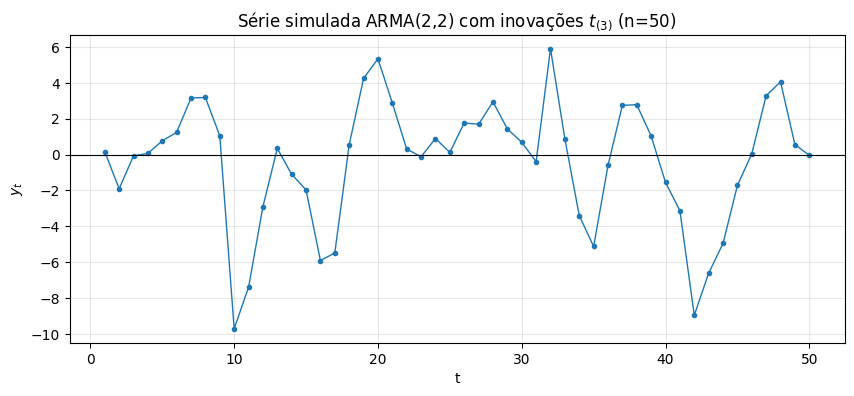

,y
count,50.0000
mean,-0.3795
std,3.5077
min,-9.7145
25%,-1.8610
50%,0.2352
75%,1.6284
max,5.9053


In [3]:
def simula_arma22_t3(n, phi1, phi2, theta1, theta2, burn=200, seed=RNG_SEED):
    # Simula um ARMA(2,2) com inovações t-Student(3 g.l.) via recursão direta
    rng = np.random.default_rng(seed)
    N = n + burn
    eps = stats.t.rvs(df=3, size=N, random_state=rng)
    y = np.zeros(N)
    for t in range(2, N):
        y[t] = (phi1 * y[t - 1] + phi2 * y[t - 2]
                + eps[t] + theta1 * eps[t - 1] + theta2 * eps[t - 2])
    return y[burn:], eps[burn:]

n_obs = 50
y_sim, eps_sim = simula_arma22_t3(n_obs, phi1, phi2, theta1, theta2)
y_sim = pd.Series(y_sim, index=pd.RangeIndex(1, n_obs + 1), name="y")

fig, ax = plt.subplots()
ax.plot(y_sim.index, y_sim.values, marker="o", markersize=3, linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Série simulada ARMA(2,2) com inovações $t_{(3)}$ (n=50)")
ax.set_xlabel("t"); ax.set_ylabel(r"$y_t$")
plt.show()

y_sim.describe().to_frame(name="y")

### A1. FAC e FACP

A seguir são apresentadas a função de autocorrelação (FAC) e a função de autocorrelação parcial (FACP) da série simulada, com bandas de significância aproximadas de $\pm 1{,}96/\sqrt{n} \approx \pm 0{,}28$.

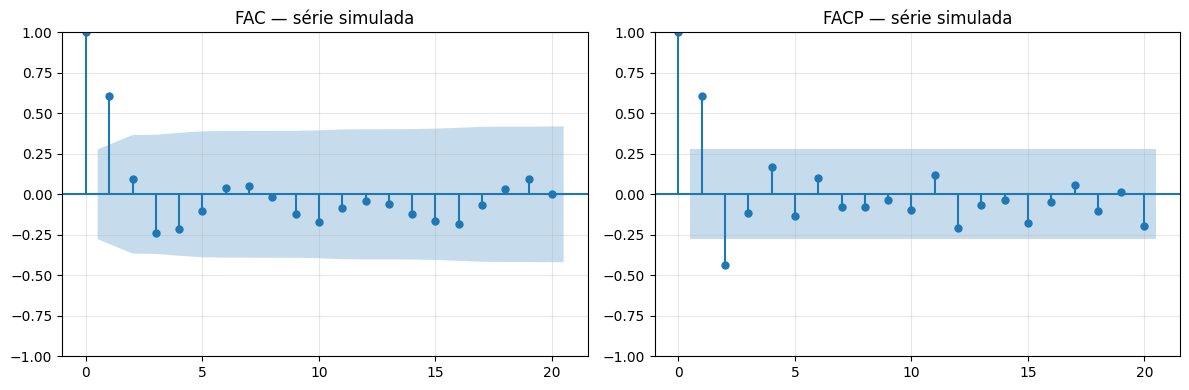

,FAC,FACP
0,1.000,1.000
1,0.609,0.609
2,0.095,-0.438
3,-0.240,-0.113
4,-0.216,0.166
5,-0.103,-0.134
6,0.041,0.099


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y_sim, lags=20, ax=axes[0], title="FAC — série simulada")
plot_pacf(y_sim, lags=20, ax=axes[1], method="ywm", title="FACP — série simulada")
plt.tight_layout()
plt.show()

tabela_correlograma = pd.DataFrame({
    "FAC": acf(y_sim, nlags=6),
    "FACP": pacf(y_sim, nlags=6, method="ywm"),
})
tabela_correlograma.round(3)

A FAC apresenta um valor elevado e estatisticamente significativo na primeira defasagem, cai de forma acentuada na segunda defasagem e, a partir daí, permanece dentro ou muito próxima da banda de significância, com alguma oscilação de sinal. Já a FACP exibe dois picos claramente significativos nas defasagens 1 e 2, tornando-se estatisticamente nula a partir da terceira defasagem. Esse padrão — FACP com corte após a defasagem 2 e FAC com decaimento relativamente rápido, porém não estritamente geométrico — é compatível tanto com um processo puramente autorregressivo de ordem 2 quanto com especificações mistas que combinem uma componente AR curta com uma componente MA. Com base nessa leitura, foram propostas três especificações candidatas:

- **Modelo 1: AR(2)** — justificado diretamente pelo corte da FACP após a defasagem 2;
- **Modelo 2: ARMA(1,1)** — especificação mista parcimoniosa, testando se um único par de termos AR/MA já é suficiente para capturar a dependência de curto prazo sugerida pela FAC;
- **Modelo 3: ARMA(2,2)** — especificação mais rica, coerente com a persistência residual observada na FAC e com maior flexibilidade para acomodar tanto a componente autorregressiva quanto a de médias móveis.

### A2. Estimação, critérios de informação e diagnóstico dos resíduos

In [5]:
especificacoes_A = {
    "Modelo 1: AR(2)": (2, 0, 0),
    "Modelo 2: ARMA(1,1)": (1, 0, 1),
    "Modelo 3: ARMA(2,2)": (2, 0, 2),
}

resultados_A = {}
for nome, ordem in especificacoes_A.items():
    resultados_A[nome] = ARIMA(y_sim, order=ordem, trend="c").fit()

for nome, res in resultados_A.items():
    print(f"===== {nome} =====")
    print(res.summary())
    print()

===== Modelo 1: AR(2) =====
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   50
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -116.609
Date:                Tue, 08 Sep 2026   AIC                            241.219
Time:                        17:50:57   BIC                            248.867
Sample:                             0   HQIC                           244.131
                                 - 50                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3570      0.706     -0.505      0.613      -1.741       1.027
ar.L1          0.8633      0.151      5.713      0.000       0.567       1.159
ar.L2         -0.4271   

In [6]:
comparacao_A = pd.DataFrame({
    "Ordem (p,d,q)": [especificacoes_A[k] for k in resultados_A],
    "AIC": [resultados_A[k].aic for k in resultados_A],
    "BIC": [resultados_A[k].bic for k in resultados_A],
}, index=resultados_A.keys())
comparacao_A.round(3)

,"Ordem (p,d,q)",AIC,BIC
Modelo 1: AR(2),"(2, 0, 0)",241.219,248.867
"Modelo 2: ARMA(1,1)","(1, 0, 1)",245.906,253.555
"Modelo 3: ARMA(2,2)","(2, 0, 2)",243.763,255.235


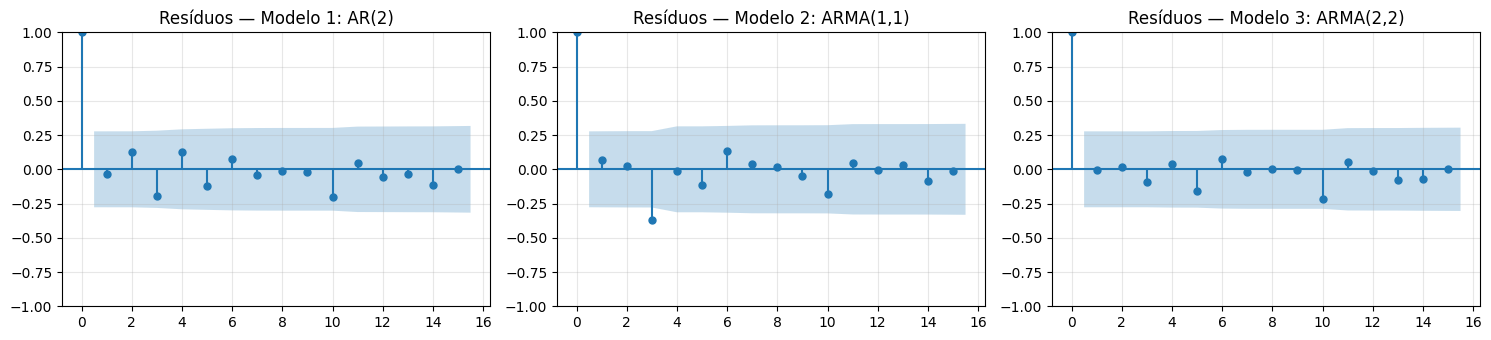

,p-valor Ljung-Box (defasagem 1),p-valor Ljung-Box (defasagem 2),p-valor Ljung-Box (defasagem 3),p-valor Ljung-Box (defasagem 4)
Modelo 1: AR(2),0.797,0.626,0.391,0.420
"Modelo 2: ARMA(1,1)",0.608,0.859,0.051,0.100
"Modelo 3: ARMA(2,2)",0.957,0.992,0.923,0.967


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, nome in zip(axes, resultados_A):
    plot_acf(resultados_A[nome].resid, lags=15, ax=ax, title=f"Resíduos — {nome}")
plt.tight_layout()
plt.show()

lb_A = {}
for nome, res in resultados_A.items():
    lb = acorr_ljungbox(res.resid, lags=[1, 2, 3, 4])
    lb_A[nome] = lb["lb_pvalue"].values

tabela_lb_A = pd.DataFrame(
    lb_A, index=[f"p-valor Ljung-Box (defasagem {i})" for i in [1, 2, 3, 4]]
).T
tabela_lb_A.round(3)

### A3. Escolha do melhor modelo

Os três modelos foram comparados a partir dos critérios de informação e dos testes de diagnóstico dos resíduos apresentados em A2. O **Modelo 1 (AR(2))** obteve os menores valores de AIC e de BIC entre as três especificações, e seus resíduos não rejeitam a hipótese nula de ausência de autocorrelação em nenhuma das quatro primeiras defasagens do teste de Ljung-Box (todos os p-valores acima de 5%), com correlogramas de resíduos sem padrões aparentes.

O Modelo 2 (ARMA(1,1)) apresentou critérios de informação piores do que os do Modelo 1 e um p-valor de Ljung-Box próximo do limiar de 5% na terceira defasagem, indicando um ajuste de resíduos ligeiramente inferior. O Modelo 3 (ARMA(2,2)) — que corresponde à forma verdadeira do processo gerador dos dados — apresentou os p-valores de Ljung-Box mais altos entre os três (resíduos mais próximos de ruído branco), o que é esperado dado o maior número de parâmetros disponíveis para absorver autocorrelação; entretanto, essa flexibilidade adicional é penalizada pelos critérios de informação, sobretudo pelo BIC, resultando em valores piores do que os do Modelo 1.

Diante desse conjunto de evidências, o **Modelo 1 (AR(2))** foi selecionado como o mais adequado: além de apresentar os menores AIC e BIC, seus resíduos já se comportam como ruído branco nas defasagens testadas, de modo que a especificação mais parcimoniosa é preferível à mais parametrizada. Esse resultado ilustra um ponto importante em amostras pequenas ($n=50$): mesmo quando o processo gerador verdadeiro é um ARMA(2,2), os critérios de informação podem favorecer uma especificação mais parcimoniosa, pela penalização imposta ao número de parâmetros estimados.

## Bloco B — Modelagem ARIMA de série real

### B1. Descrição da série

A série escolhida foi o **Índice de Produção Física Industrial — Indústria Geral, com ajuste sazonal** (base fixa 2012 = 100), divulgado pelo IBGE (Pesquisa Industrial Mensal — PIM-PF) e disponibilizado pelo Banco Central do Brasil no Sistema Gerenciador de Séries Temporais (SGS), código 21859. A série mede a evolução do volume físico da produção da indústria brasileira e é amplamente utilizada como indicador de curto prazo da atividade do setor industrial, funcionando como *proxy* mensal e de maior frequência do que o PIB trimestral. Foram utilizadas observações mensais de janeiro de 2002 a junho de 2026, período que excede amplamente o mínimo de 120 observações exigido para séries mensais.

(294,) 2002-01-01 a 2026-06-01


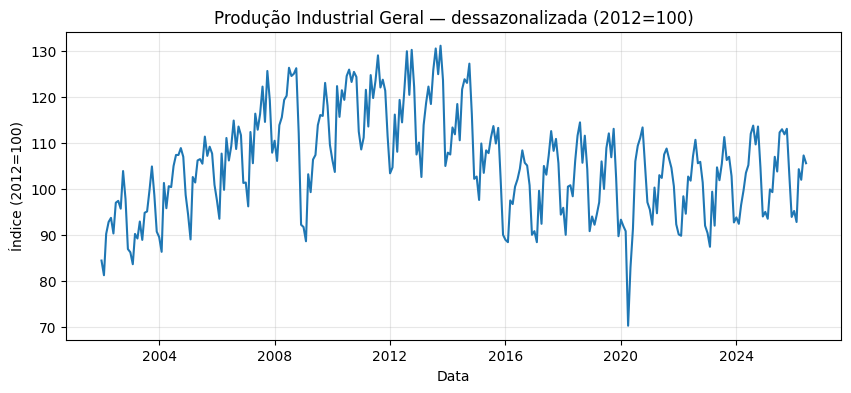

In [8]:
CAMINHO_DADOS = "data/pim_pf.csv"

try:
    pim = pd.read_csv(CAMINHO_DADOS, parse_dates=["data"], index_col="data").asfreq("MS")["pim"]
except FileNotFoundError:
    from bcb import sgs
    pim = sgs.get({"pim": 21859}, start="2002-01-01").asfreq("MS")["pim"]
    pim.rename_axis("data").to_frame().to_csv(CAMINHO_DADOS)

print(pim.shape, pim.index.min().date(), "a", pim.index.max().date())

fig, ax = plt.subplots()
ax.plot(pim.index, pim.values)
ax.set_title("Produção Industrial Geral — dessazonalizada (2012=100)")
ax.set_xlabel("Data"); ax.set_ylabel("Índice (2012=100)")
plt.show()

### B2. Estacionarização

Para investigar a ordem de integração da série, foram aplicados os testes de raiz unitária Augmented Dickey-Fuller (ADF — hipótese nula de raiz unitária) e KPSS (hipótese nula de estacionariedade) sobre o nível, o logaritmo do nível e a primeira diferença do logaritmo (variação percentual mensal aproximada).

In [9]:
log_pim = np.log(pim)
dlog_pim = log_pim.diff().dropna()

series_para_teste = {"Nível": pim, "Log-nível": log_pim, "Log-diferença": dlog_pim}
linhas = []
for nome, serie in series_para_teste.items():
    adf_stat, adf_p, *_ = adfuller(serie, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")
    linhas.append([nome, adf_stat, adf_p, kpss_stat, kpss_p])

tabela_raiz_unitaria = pd.DataFrame(
    linhas, columns=["Série", "ADF (estat.)", "ADF (p-valor)", "KPSS (estat.)", "KPSS (p-valor)"]
).set_index("Série")
tabela_raiz_unitaria.round(4)

C:\Users\tomas\AppData\Local\Temp\ipykernel_13000\3868368975.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie, regression="c", nlags="auto")


,ADF (estat.),ADF (p-valor),KPSS (estat.),KPSS (p-valor)
Série,,,,
Nível,-2.3371,0.1603,0.5569,0.0289
Log-nível,-2.3823,0.1468,0.5402,0.0326
Log-diferença,-4.7655,0.0001,0.0315,0.1000


Tanto em nível quanto em log-nível, o teste ADF não rejeita a hipótese nula de raiz unitária (p-valor bem acima de 5%) e o teste KPSS rejeita a hipótese nula de estacionariedade (p-valor abaixo de 5%) — ambos os testes concordam que a série em nível é não estacionária. Já para a primeira diferença do logaritmo, o ADF rejeita fortemente a raiz unitária (p-valor $\approx 0{,}0001$) e o KPSS não rejeita estacionariedade (p-valor no limite superior tabelado, $\geq 0{,}10$), concordância que indica que a série se torna estacionária após uma diferenciação do logaritmo. O procedimento adotado para estacionarizar a série foi, portanto, tomar o logaritmo do índice e aplicar a primeira diferença, o que corresponde aproximadamente à taxa de crescimento mensal da produção industrial.

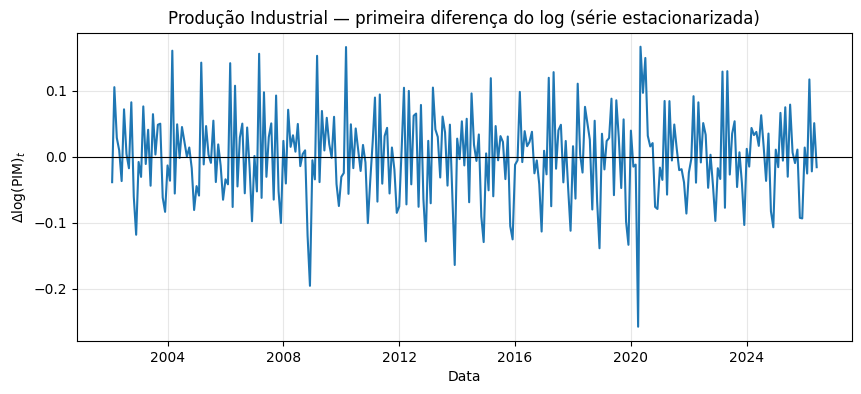

In [10]:
fig, ax = plt.subplots()
ax.plot(dlog_pim.index, dlog_pim.values)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Produção Industrial — primeira diferença do log (série estacionarizada)")
ax.set_xlabel("Data"); ax.set_ylabel(r"$\Delta \log(\mathrm{PIM})_t$")
plt.show()

### B3. Correlograma e especificações propostas

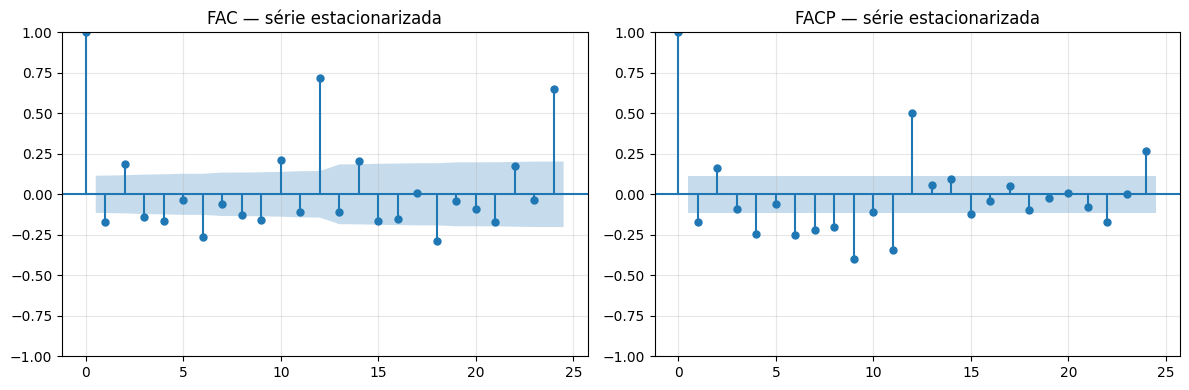

n = 293, banda de significância aproximada: +/- 0.115


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(dlog_pim, lags=24, ax=axes[0], title="FAC — série estacionarizada")
plot_pacf(dlog_pim, lags=24, ax=axes[1], method="ywm", title="FACP — série estacionarizada")
plt.tight_layout()
plt.show()

banda_95 = 1.96 / np.sqrt(len(dlog_pim))
print(f"n = {len(dlog_pim)}, banda de significância aproximada: +/- {banda_95:.3f}")

Com $n=293$ observações estacionarizadas, a banda de significância aproximada é de $\pm 0{,}115$. Ambos os correlogramas mostram um valor negativo e significativo na primeira defasagem (FAC $\approx -0{,}17$; FACP $\approx -0{,}17$), seguido por oscilações de menor magnitude nas defasagens intermediárias. Chama atenção um pico bastante pronunciado na defasagem 12 (FAC $\approx 0{,}72$; FACP $\approx 0{,}50$): mesmo em uma série divulgada como dessazonalizada, é comum que reste algum resíduo de sazonalidade não plenamente removido pelo procedimento de ajuste do IBGE. Como o enunciado pede modelos ARMA(p,q) não sazonais, a modelagem a seguir concentra-se no padrão de curto prazo (defasagens 1 e 2), deixando explicitamente registrado que uma extensão natural — fora do escopo deste exercício — seria a inclusão de termos sazonais (SARIMA) para tratar o pico na defasagem 12.

Com base no padrão de curto prazo, foram propostas três especificações:

- **Modelo 1: MA(1)** — a FAC é significativa apenas na primeira defasagem antes de se aproximar da banda, um padrão típico de corte associado a processos de médias móveis de primeira ordem;
- **Modelo 2: AR(1)** — a FACP também exibe seu maior valor em módulo na primeira defasagem, padrão compatível com um processo autorregressivo de primeira ordem;
- **Modelo 3: ARMA(1,1)** — especificação mista que combina as duas componentes identificadas, servindo como alternativa mais flexível às duas anteriores.

### B4. Estimação e diagnóstico

In [12]:
especificacoes_B = {
    "Modelo 1: MA(1)": (0, 0, 1),
    "Modelo 2: AR(1)": (1, 0, 0),
    "Modelo 3: ARMA(1,1)": (1, 0, 1),
}

resultados_B = {}
for nome, ordem in especificacoes_B.items():
    resultados_B[nome] = ARIMA(dlog_pim, order=ordem, trend="c").fit()

for nome, res in resultados_B.items():
    print(f"===== {nome} =====")
    print(res.summary())
    print()

===== Modelo 1: MA(1) =====
                               SARIMAX Results                                
Dep. Variable:                    pim   No. Observations:                  293
Model:                 ARIMA(0, 0, 1)   Log Likelihood                 385.272
Date:                Tue, 08 Sep 2026   AIC                           -764.544
Time:                        17:50:58   BIC                           -753.503
Sample:                    02-01-2002   HQIC                          -760.122
                         - 06-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.004      0.217      0.828      -0.006       0.008
ma.L1         -0.1341      0.062     -2.156      0.031      -0.256      -0.012
sigma2         0.0042   

C:\Users\tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
comparacao_B = pd.DataFrame({
    "Ordem (p,d,q)": [especificacoes_B[k] for k in resultados_B],
    "AIC": [resultados_B[k].aic for k in resultados_B],
    "BIC": [resultados_B[k].bic for k in resultados_B],
}, index=resultados_B.keys())
comparacao_B.round(3)

,"Ordem (p,d,q)",AIC,BIC
Modelo 1: MA(1),"(0, 0, 1)",-764.544,-753.503
Modelo 2: AR(1),"(1, 0, 0)",-766.671,-755.630
"Modelo 3: ARMA(1,1)","(1, 0, 1)",-785.507,-770.786


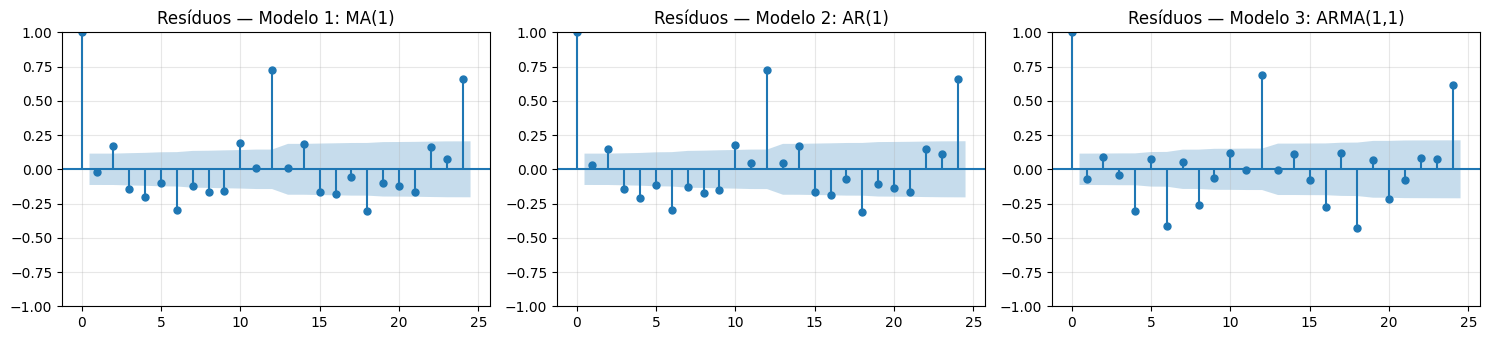

,p-valor Ljung-Box (defasagem 1),p-valor Ljung-Box (defasagem 2),p-valor Ljung-Box (defasagem 3),p-valor Ljung-Box (defasagem 4)
Modelo 1: MA(1),0.734,0.014,0.002,0.0
Modelo 2: AR(1),0.626,0.040,0.005,0.0
"Modelo 3: ARMA(1,1)",0.204,0.126,0.200,0.0


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, nome in zip(axes, resultados_B):
    plot_acf(resultados_B[nome].resid, lags=24, ax=ax, title=f"Resíduos — {nome}")
plt.tight_layout()
plt.show()

lb_B = {}
for nome, res in resultados_B.items():
    lb = acorr_ljungbox(res.resid, lags=[1, 2, 3, 4])
    lb_B[nome] = lb["lb_pvalue"].values

tabela_lb_B = pd.DataFrame(
    lb_B, index=[f"p-valor Ljung-Box (defasagem {i})" for i in [1, 2, 3, 4]]
).T
tabela_lb_B.round(3)

Um ponto a destacar na estimação do Modelo 3 (ARMA(1,1)) é que os coeficientes AR e MA convergiram para valores muito próximos em magnitude e de sinais opostos (aproximadamente $\hat\phi_1 \approx -1{,}00$ e $\hat\theta_1 \approx 0{,}998$). Esse padrão caracteriza um problema de **fator comum** entre os polinômios AR e MA: quando as raízes dos dois polinômios praticamente se cancelam, o modelo se torna quase observacionalmente equivalente a ruído branco e os parâmetros deixam de ser identificados com precisão, mesmo que o ajuste numérico (e, por consequência, o AIC/BIC) pareça favorável.

### B5. Escolha do melhor modelo

Excluindo o Modelo 3 pelo problema de fator comum descrito acima — que compromete a interpretabilidade de seus coeficientes, independentemente dos critérios de informação —, a comparação relevante ocorre entre os Modelos 1 (MA(1)) e 2 (AR(1)). O Modelo 2 (AR(1)) apresenta AIC e BIC ligeiramente menores do que os do Modelo 1, sendo por esse critério a especificação preferida.

Quanto ao diagnóstico de resíduos, nenhum dos dois modelos elimina completamente a autocorrelação: os testes de Ljung-Box não rejeitam a ausência de autocorrelação na primeira defasagem, mas rejeitam a partir da segunda ou terceira defasagem, refletindo o padrão de resíduo sazonal (pico na defasagem 12) e alguma dependência de curto prazo que uma especificação puramente AR(1)/MA(1) não é capaz de capturar por completo. Ainda assim, entre as três alternativas propostas, o **Modelo 2 (AR(1))** foi selecionado como o mais adequado, por combinar identificabilidade dos parâmetros com o melhor desempenho nos critérios de informação. Registra-se como limitação que uma modelagem mais completa dessa série — fora do escopo deste exercício, que pede apenas especificações ARMA(p,q) não sazonais — provavelmente exigiria uma estrutura sazonal explícita (SARIMA) para tratar integralmente o padrão residual na defasagem 12.

## Bloco C — Filtro de tendência e ciclo

Para este bloco, foi utilizada a mesma série de produção industrial do Bloco B (em log-nível, $\log(\mathrm{PIM}_t)$), decomposta em componentes de tendência e ciclo por meio de três filtros distintos: o filtro de Hodrick-Prescott, o filtro de Hamilton e um terceiro filtro construído a partir da combinação do filtro de Hamilton com um polinômio determinístico.

### C1. Estimação da tendência pelos três filtros

**Filtro de Hodrick-Prescott (HP).** O filtro HP decompõe a série $y_t$ em tendência $\tau_t$ e ciclo $c_t = y_t - \tau_t$, escolhendo $\tau_t$ como solução do problema de minimização

$$\min_{\{\tau_t\}} \sum_{t=1}^{T} (y_t - \tau_t)^2 + \lambda \sum_{t=2}^{T-1} \big[(\tau_{t+1} - \tau_t) - (\tau_t - \tau_{t-1})\big]^2$$

em que o parâmetro de suavização $\lambda$ pondera a penalidade sobre a curvatura da tendência. Para dados mensais, foi utilizado o valor convencional $\lambda = 129.600$ (equivalente ao $\lambda=1.600$ recomendado para dados trimestrais, escalado pela quarta potência da razão entre as frequências, conforme sugerido por Ravn e Uhlig, 2002).

**Filtro de Hamilton.** Hamilton (2018) propõe substituir o filtro HP — que apresenta propriedades estatísticas indesejáveis, como a geração de dinâmicas espúrias no componente cíclico — por uma projeção linear simples de $y_{t+h}$ sobre $p$ defasagens de $y_t$ observadas até o período $t$:

$$y_{t+h} = \beta_0 + \beta_1 y_t + \beta_2 y_{t-1} + \dots + \beta_p y_{t-p+1} + u_{t+h}$$

A tendência estimada é o valor ajustado $\hat y_{t+h|t}$ dessa regressão, e o ciclo é o resíduo $u_{t+h} = y_{t+h} - \hat y_{t+h|t}$. Hamilton sugere, para dados trimestrais, $h=8$ (dois anos à frente) e $p=4$; nesta aplicação, com dados mensais, essa recomendação foi escalada proporcionalmente à frequência, utilizando $h=24$ (dois anos à frente, em meses) e $p=12$ (doze defasagens mensais).

**Terceiro filtro (Hamilton + polinômio determinístico).** Para permitir que a tendência combine a projeção autorregressiva de Hamilton com uma componente determinística suave, a regressão anterior foi ampliada com um polinômio de ordem $n=3$ na tendência temporal $t$:

$$y_{t+h} = \beta_0 + \sum_{j=0}^{p-1}\beta_{1+j}\, y_{t-j} + \gamma_1 t + \gamma_2 t^2 + \gamma_3 t^3 + u_{t+h}$$

Os mesmos valores $h=24$ e $p=12$ foram mantidos, e a ordem $n=3$ (polinômio cúbico) foi escolhida por ser suficientemente flexível para acomodar mudanças suaves na inclinação da tendência ao longo de mais de duas décadas, sem introduzir oscilações de alta frequência que a tornariam indistinguível do próprio ciclo.

In [15]:
log_pim = np.log(pim)

# Filtro HP
ciclo_hp, tendencia_hp = hpfilter(log_pim, lamb=129600)

# Filtro de Hamilton (regressao) e sua extensao com polinomio determinístico
def filtro_hamilton(y, p=12, h=24, regressores_extra=None):
    idx = y.index
    X = pd.DataFrame({f"lag{j}": y.shift(h + j) for j in range(p)})
    if regressores_extra is not None:
        X = pd.concat([X, regressores_extra], axis=1)
    X = sm.add_constant(X)
    dados = pd.concat([y.rename("y"), X], axis=1).dropna()
    modelo = sm.OLS(dados["y"], dados.drop(columns="y")).fit()
    tendencia = pd.Series(index=idx, dtype=float)
    tendencia.loc[dados.index] = modelo.predict(dados.drop(columns="y"))
    ciclo = y - tendencia
    return tendencia, ciclo, modelo

tendencia_ham, ciclo_ham, modelo_ham = filtro_hamilton(log_pim, p=12, h=24)

t_idx = pd.Series(np.arange(len(log_pim)), index=log_pim.index)
poly_det = pd.DataFrame({f"t{k}": t_idx ** k for k in range(1, 4)})
tendencia_ham_poly, ciclo_ham_poly, modelo_ham_poly = filtro_hamilton(
    log_pim, p=12, h=24, regressores_extra=poly_det
)

print(f"R² do filtro de Hamilton: {modelo_ham.rsquared:.3f}")
print(f"R² do filtro de Hamilton + polinômio: {modelo_ham_poly.rsquared:.3f}")

R² do filtro de Hamilton: 0.518
R² do filtro de Hamilton + polinômio: 0.701


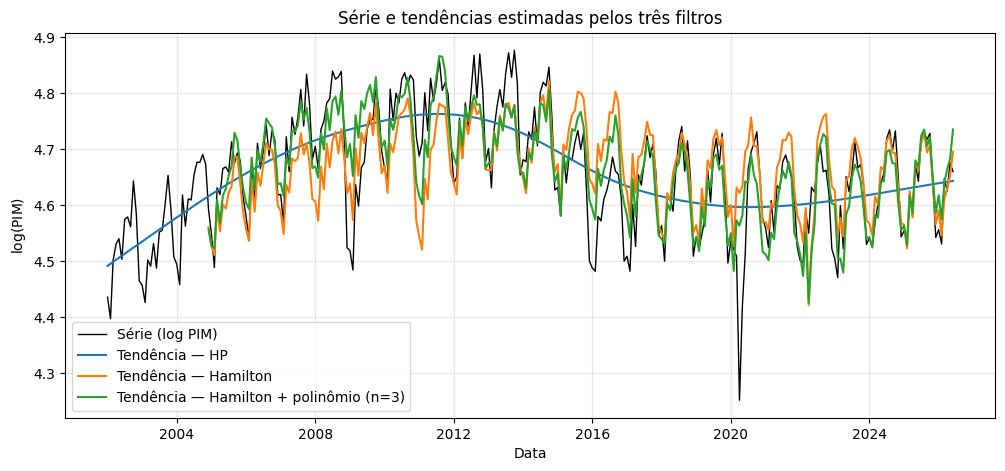

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(log_pim.index, log_pim.values, label="Série (log PIM)", color="black", linewidth=1)
ax.plot(tendencia_hp.index, tendencia_hp.values, label="Tendência — HP", linewidth=1.5)
ax.plot(tendencia_ham.index, tendencia_ham.values, label="Tendência — Hamilton", linewidth=1.5)
ax.plot(tendencia_ham_poly.index, tendencia_ham_poly.values, label="Tendência — Hamilton + polinômio (n=3)", linewidth=1.5)
ax.set_title("Série e tendências estimadas pelos três filtros")
ax.set_xlabel("Data"); ax.set_ylabel(r"$\log(\mathrm{PIM})$")
ax.legend()
plt.show()

A tendência estimada pelo filtro HP acompanha de perto a própria série, capturando inclusive parte das oscilações de curto prazo — reflexo da conhecida tendência do filtro HP a produzir uma tendência excessivamente flexível, "vazando" ciclo para dentro da tendência. A tendência de Hamilton, por ser calculada apenas a partir de defasagens observadas até $t$ (sem usar informação futura na construção da própria observação, ainda que o alinhamento com $h=24$ à frente implique perda das primeiras observações da amostra), aparece mais suave e menos sensível a oscilações de curto prazo, embora ainda reaja a mudanças de médio prazo no nível da série. Já a tendência do terceiro filtro (Hamilton + polinômio cúbico) é a mais suave das três, pois o componente polinomial determinístico impõe uma trajetória de longo prazo mais rígida, deixando para o resíduo (ciclo) boa parte das flutuações de médio prazo que o filtro de Hamilton puro ainda atribuía à tendência.

### C2. Comparação dos ciclos estimados

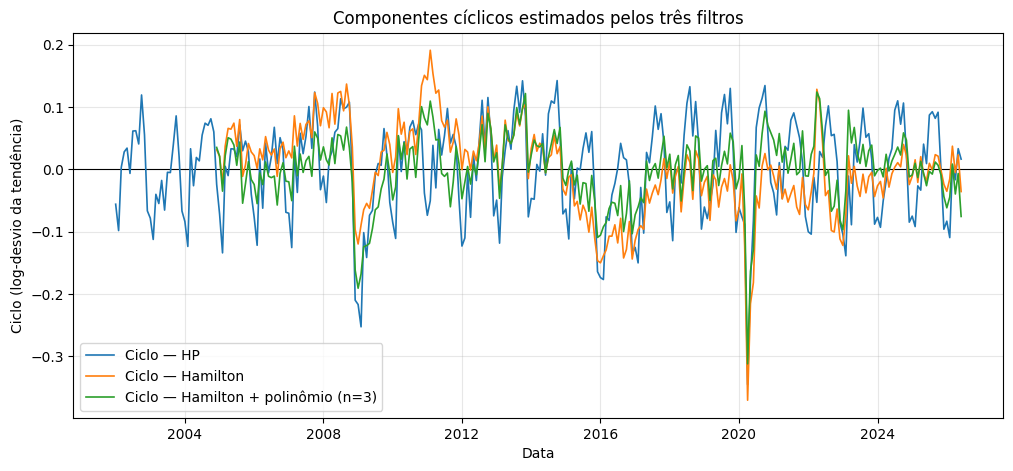

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axhline(0, color="black", linewidth=0.8)
ax.plot(ciclo_hp.index, ciclo_hp.values, label="Ciclo — HP", linewidth=1.2)
ax.plot(ciclo_ham.index, ciclo_ham.values, label="Ciclo — Hamilton", linewidth=1.2)
ax.plot(ciclo_ham_poly.index, ciclo_ham_poly.values, label="Ciclo — Hamilton + polinômio (n=3)", linewidth=1.2)
ax.set_title("Componentes cíclicos estimados pelos três filtros")
ax.set_xlabel("Data"); ax.set_ylabel("Ciclo (log-desvio da tendência)")
ax.legend()
plt.show()

Os três ciclos compartilham os mesmos pontos de inflexão principais — quedas acentuadas associadas à crise financeira de 2008-09, à recessão brasileira de 2015-16 e, de forma particularmente aguda, à pandemia de Covid-19 em 2020 —, mas diferem consideravelmente em amplitude e suavidade. O ciclo do filtro HP é o mais suave e de menor amplitude nos picos, consistente com uma tendência mais flexível que absorve parte do movimento cíclico. O ciclo de Hamilton apresenta maior volatilidade de curto prazo, incluindo algum ruído de alta frequência que não parece refletir flutuações econômicas genuínas. O ciclo do terceiro filtro (Hamilton + polinômio) situa-se entre os dois em termos de suavidade, mas exibe a queda mais acentuada durante a pandemia, precisamente porque sua tendência determinística mais rígida não se ajusta ao choque abrupto, atribuindo-o quase inteiramente ao componente cíclico.

Dentre os três, o ciclo do **terceiro filtro (Hamilton + polinômio de ordem 3)** é considerado o mais razoável para fins de análise conjuntural: ele evita tanto o excesso de suavização da tendência (problema do HP) quanto o ruído de curto prazo do filtro de Hamilton puro, ao mesmo tempo em que preserva de forma nítida os episódios recessivos conhecidos da economia brasileira no período.

### C3. Correlograma e estatísticas descritivas dos ciclos

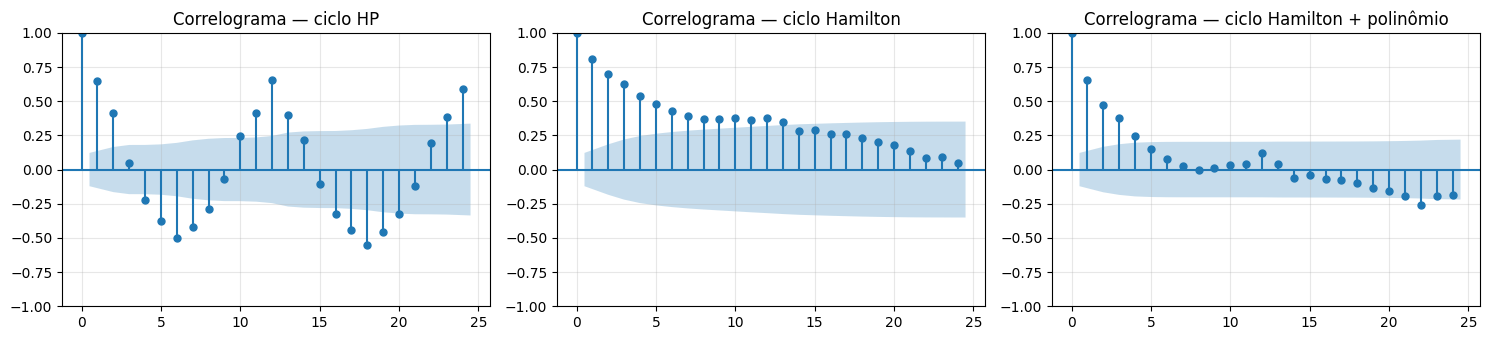

,count,mean,std,min,25%,50%,75%,max,assimetria,curtose
HP,259.0,-0.0002,0.0793,-0.3452,-0.0576,0.0121,0.0567,0.1424,-0.7134,0.8198
Hamilton,259.0,0.0000,0.0704,-0.3703,-0.0380,0.0035,0.0399,0.1911,-0.6504,2.6021
Hamilton + polinômio,259.0,-0.0000,0.0554,-0.3119,-0.0233,0.0058,0.0368,0.1241,-1.1752,4.1478


In [18]:
ciclos = pd.DataFrame({
    "HP": ciclo_hp,
    "Hamilton": ciclo_ham,
    "Hamilton + polinômio": ciclo_ham_poly,
}).dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, nome in zip(axes, ciclos.columns):
    plot_acf(ciclos[nome], lags=24, ax=ax, title=f"Correlograma — ciclo {nome}")
plt.tight_layout()
plt.show()

estatisticas_ciclos = ciclos.describe().T
estatisticas_ciclos["assimetria"] = ciclos.skew()
estatisticas_ciclos["curtose"] = ciclos.kurtosis()
estatisticas_ciclos.round(4)

In [19]:
ciclos.corr().round(3)

,HP,Hamilton,Hamilton + polinômio
HP,1.000,0.505,0.641
Hamilton,0.505,1.000,0.787
Hamilton + polinômio,0.641,0.787,1.000


Os correlogramas mostram que os três ciclos são autocorrelacionados de forma persistente e com decaimento lento — comportamento típico de um componente cíclico de negócios, com duração de vários trimestres —, ainda que o ciclo de Hamilton exiba autocorrelações de curto prazo (defasagens 1-2) menos suaves do que as dos outros dois, refletindo o ruído de alta frequência mencionado em C2.

Quanto às estatísticas descritivas, as três séries têm média muito próxima de zero (por construção) e apresentam assimetria negativa e curtose positiva (caudas mais pesadas do que a normal), refletindo a presença de quedas abruptas e pouco frequentes (crises) contra um padrão mais gradual de recuperação. O ciclo do terceiro filtro é o que apresenta maior curtose e assimetria mais negativa em magnitude, exatamente porque concentra de forma mais extrema o choque da pandemia. Em termos de dispersão, o ciclo HP tem o maior desvio-padrão e o do terceiro filtro o menor.

A matriz de correlação indica que os resultados **não são muito similares** entre si: a correlação entre os ciclos de HP e de Hamilton é apenas moderada, e a correlação entre HP e o terceiro filtro é um pouco mais alta; a maior correlação ocorre entre o filtro de Hamilton e sua extensão com polinômio determinístico — o que é esperado, dado que os dois compartilham a mesma projeção autorregressiva de base, diferindo apenas quanto à inclusão (ou não) da componente polinomial na tendência. Essas diferenças reforçam a conclusão de C1/C2 de que a escolha do filtro de tendência-ciclo não é uma decisão inócua: filtros distintos, mesmo quando aplicados à mesma série, podem levar a leituras econômicas differentes sobre a magnitude e a datação dos ciclos de negócios.